In [1]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 76.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [ ]:
import os
#import json
import warnings
warnings.filterwarnings("ignore")

import mlflow
import mlflow.sklearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

# End any old unfinished run
mlflow.end_run()

# IMPORTANT: set tracking DB explicitly
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Insider_Threat_Detection")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("All imports OK")

2026/04/09 08:15:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/09 08:15:25 INFO mlflow.store.db.utils: Updating database tables
2026/04/09 08:15:27 INFO mlflow.tracking.fluent: Experiment with name 'Insider_Threat_Detection' does not exist. Creating a new experiment.


MLflow tracking URI: sqlite:///mlflow.db
All imports OK


In [ ]:

# DATA LOADING

DATA_FILE = "insider_threat_clean_dataset.csv"   # change only if needed

with mlflow.start_run(run_name="data_loading"):
    df = pd.read_csv(DATA_FILE)

    mlflow.log_param("dataset", DATA_FILE)
    mlflow.log_param("num_rows", df.shape[0])
    mlflow.log_param("num_cols", df.shape[1])

    dataset_summary = pd.DataFrame({
        "metric": ["num_rows", "num_cols"],
        "value": [df.shape[0], df.shape[1]]
    })
    dataset_summary.to_csv("dataset_summary.csv", index=False)
    mlflow.log_artifact("dataset_summary.csv")

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
display(df.head())
display(df.describe(include='all'))
df.info()


Shape: (118614, 22)

Columns:
 Index(['employee_department', 'employee_campus', 'employee_position',
       'employee_seniority_years', 'is_contractor', 'employee_classification',
       'has_foreign_citizenship', 'has_criminal_record', 'has_medical_history',
       'employee_origin_country', 'total_printed_pages',
       'num_printed_pages_off_hours', 'total_files_burned',
       'burned_from_other', 'is_abroad', 'trip_day_number',
       'hostility_country_level', 'num_entries', 'num_unique_campus',
       'late_exit_flag', 'entry_during_weekend', 'is_malicious'],
      dtype='object')


,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,4,0,0,0.0,0,1,1,0,1,0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,2,0,0,0.0,0,1,1,0,0,0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,0,0,0,0,0


,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
count,118614,118614,118614,118614.000000,118614.000000,118614.000000,118614.000000,118614.000000,118614.000000,118614,...,118614.000000,118614.000000,118614.000000,118614.000000,118614.000000,118614.000000,118614.000000,118614.0,118614.00000,118614.000000
unique,11,3,48,NaN,NaN,NaN,NaN,NaN,NaN,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R&D Department,Campus C,Secretary,NaN,NaN,NaN,NaN,NaN,NaN,Israel,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,23796,40156,20515,NaN,NaN,NaN,NaN,NaN,NaN,49972,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,12.371508,0.140616,1.889743,0.163168,0.049311,0.151340,NaN,...,9.380815,0.007234,0.041825,0.223397,0.005564,0.746261,0.597948,0.0,0.05061,0.053839
std,NaN,NaN,NaN,7.195372,0.347626,0.749889,0.369520,0.216518,0.358381,NaN,...,19.724109,0.084742,0.200189,1.270251,0.110730,0.738767,0.534381,0.0,0.21920,0.225700
min,NaN,NaN,NaN,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000
25%,NaN,NaN,NaN,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.000000
50%,NaN,NaN,NaN,12.000000,0.000000,2.000000,0.000000,0.000000,0.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.00000,0.000000
75%,NaN,NaN,NaN,18.000000,0.000000,2.000000,0.000000,0.000000,0.000000,NaN,...,7.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.0,0.00000,0.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118614 entries, 0 to 118613
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_department          118614 non-null  object 
 1   employee_campus              118614 non-null  object 
 2   employee_position            118614 non-null  object 
 3   employee_seniority_years     118614 non-null  int64  
 4   is_contractor                118614 non-null  int64  
 5   employee_classification      118614 non-null  int64  
 6   has_foreign_citizenship      118614 non-null  int64  
 7   has_criminal_record          118614 non-null  int64  
 8   has_medical_history          118614 non-null  int64  
 9   employee_origin_country      118614 non-null  object 
 10  total_printed_pages          118614 non-null  int64  
 11  num_printed_pages_off_hours  118614 non-null  int64  
 12  total_files_burned           118614 non-null  int64  
 13 

In [ ]:
# EDA / CORRELATION HEATMAP
with mlflow.start_run(run_name="EDA"):
    corr = df.corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.savefig("correlation_heatmap.png", bbox_inches="tight")
    plt.close()

    corr.to_csv("correlation_matrix.csv")
    mlflow.log_artifact("correlation_heatmap.png")
    mlflow.log_artifact("correlation_matrix.csv")
display(corr.head())


,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
employee_seniority_years,1.000000,-0.034374,0.058729,-0.034867,-0.012192,0.033904,-0.025595,0.009324,0.049628,0.020176,-0.003038,-0.004181,0.012664,0.008048,0.010706,NaN,0.013058,0.045448
is_contractor,-0.034374,1.000000,-0.010059,-0.013880,0.004093,-0.032766,-0.002875,-0.010912,-0.015721,-0.011061,-0.006372,-0.008421,-0.013318,-0.001966,-0.002141,NaN,0.001315,-0.029547
employee_classification,0.058729,-0.010059,1.000000,0.002736,-0.004627,-0.020666,-0.158511,-0.027081,0.129789,0.030328,0.038132,0.026796,0.005053,0.013158,0.013843,NaN,0.039897,0.049519
has_foreign_citizenship,-0.034867,-0.013880,0.002736,1.000000,0.024724,-0.015344,0.028814,0.004407,-0.003620,0.012924,-0.015098,-0.011902,-0.004675,0.005586,0.007699,NaN,0.001718,0.020623
has_criminal_record,-0.012192,0.004093,-0.004627,0.024724,1.000000,0.019211,0.004579,-0.003847,-0.028815,-0.015765,-0.002846,-0.003514,-0.011445,-0.002418,-0.003089,NaN,-0.007819,-0.034660


In [ ]:

# PREPROCESSING

with mlflow.start_run(run_name="preprocessing"):
    df_processed = df.drop(columns=["late_exit_flag"])

    X = df_processed.drop(columns=["is_malicious"])
    y = df_processed["is_malicious"]

    mlflow.log_param("dropped_column", "late_exit_flag")
    mlflow.log_param("target", "is_malicious")

    cat_cols = [
        "employee_department",
        "employee_campus",
        "employee_position",
        "employee_origin_country"
    ]

    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("random_state", 42)
    mlflow.log_param("stratify", True)
    mlflow.log_param("encoding", "pd.get_dummies(drop_first=True)")
    mlflow.log_metric("train_rows", X_train.shape[0])
    mlflow.log_metric("test_rows", X_test.shape[0])
    mlflow.log_metric("num_features_after_encoding", X.shape[1])
    mlflow.log_metric("positive_class_ratio", float(y.mean()))

    pd.DataFrame({"feature_name": X.columns}).to_csv("encoded_feature_names.csv", index=False)
    mlflow.log_artifact("encoded_feature_names.csv")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (94891, 106)
X_test shape: (23723, 106)
y_train shape: (94891,)
y_test shape: (23723,)


In [ ]:

#LOGISTIC REGRESSION MODEL + ARTIFACTS

with mlflow.start_run(run_name="Logistic_Regression"):
    log_model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )

    log_model.fit(X_train, y_train)

    log_y_pred = log_model.predict(X_test)
    log_y_prob = log_model.predict_proba(X_test)[:, 1]

    log_roc_auc = roc_auc_score(y_test, log_y_prob)
    log_pr_auc = average_precision_score(y_test, log_y_prob)
    log_f1 = f1_score(y_test, log_y_pred)
    log_acc = accuracy_score(y_test, log_y_pred)

    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("class_weight", "balanced")

    mlflow.log_metric("roc_auc", log_roc_auc)
    mlflow.log_metric("pr_auc", log_pr_auc)
    mlflow.log_metric("f1_score", log_f1)
    mlflow.log_metric("accuracy", log_acc)

    mlflow.sklearn.log_model(log_model, "model")

    # classification report
    log_report = classification_report(y_test, log_y_pred)
    with open("logistic_classification_report.txt", "w") as f:
        f.write(log_report)
    mlflow.log_artifact("logistic_classification_report.txt")

    # confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_test, log_y_pred, cmap="Blues")
    plt.title("Logistic Regression Confusion Matrix")
    plt.tight_layout()
    plt.savefig("logistic_confusion_matrix.png", bbox_inches="tight")
    plt.close()
    mlflow.log_artifact("logistic_confusion_matrix.png")

    # PR curve
    precision, recall, thresholds = precision_recall_curve(y_test, log_y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"PR AUC = {log_pr_auc:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Logistic Regression PR Curve")
    plt.legend()
    plt.tight_layout()
    plt.savefig("logistic_pr_curve.png", bbox_inches="tight")
    plt.close()
    mlflow.log_artifact("logistic_pr_curve.png")

    # feature importance
    importance = pd.Series(log_model.coef_[0], index=X.columns).sort_values(ascending=False)
    importance_df = importance.reset_index()
    importance_df.columns = ["feature", "coefficient"]
    importance_df.to_csv("logistic_feature_importance.csv", index=False)
    mlflow.log_artifact("logistic_feature_importance.csv")

    plt.figure(figsize=(10, 6))
    importance.head(15).sort_values().plot(kind="barh")
    plt.title("Top Logistic Regression Positive Features")
    plt.tight_layout()
    plt.savefig("logistic_feature_importance.png", bbox_inches="tight")
    plt.close()
    mlflow.log_artifact("logistic_feature_importance.png")

    # results table
    log_results = pd.DataFrame(X_test.copy()).reset_index(drop=True)
    y_test_reset = y_test.reset_index(drop=True)
    log_results["actual"] = y_test_reset
    log_results["risk_score"] = (log_y_prob * 100).astype(int)

    def risk_level(score):
        if score < 30:
            return "Low"
        elif score < 60:
            return "Medium"
        elif score < 80:
            return "High"
        else:
            return "Critical"

    log_results["risk_level"] = log_results["risk_score"].apply(risk_level)
    log_results.to_csv("logistic_results_table.csv", index=False)
    mlflow.log_artifact("logistic_results_table.csv")

print("=== Logistic Regression ===")
print(log_report)
print("ROC-AUC:", log_roc_auc)
print("PR-AUC:", log_pr_auc)
print("F1 Score:", log_f1)
print("Accuracy:", log_acc)
display(log_results.head())


2026/04/09 08:18:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 08:18:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.99      0.89      0.93     22446
           1       0.28      0.80      0.42      1277

    accuracy                           0.88     23723
   macro avg       0.64      0.84      0.68     23723
weighted avg       0.95      0.88      0.91     23723

ROC-AUC: 0.9262924658787808
PR-AUC: 0.6153764095562236
F1 Score: 0.4192622950819672
Accuracy: 0.8805378746364287


In [ ]:
# LOGISTIC REGRESSION RESULTS TABLE (DISPLAY)

display(log_results.head())


,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,...,employee_origin_country_Syria,employee_origin_country_Tunisia,employee_origin_country_Turkey,employee_origin_country_UK,employee_origin_country_USA,employee_origin_country_Ukraine,employee_origin_country_Yemen,actual,risk_score,risk_level
0,10,1,3,0,1,0,29,0,7,0,...,False,False,False,False,False,False,False,0,18,Low
1,9,0,2,0,0,0,0,0,10,0,...,False,False,False,False,False,False,False,0,3,Low
2,5,0,1,1,0,0,44,8,10,0,...,False,False,False,False,False,False,False,0,25,Low
3,16,0,2,0,0,0,6,0,0,0,...,False,False,False,False,False,False,False,0,1,Low
4,10,0,2,0,0,0,4,0,0,0,...,False,False,False,False,False,False,False,0,39,Medium


In [8]:
# ============================================
# CELL 6: LOGISTIC REGRESSION FEATURE IMPORTANCE (DISPLAY)
# ============================================
print("Top 10 Positive Features:")
display(importance.head(10))

print("Top 10 Negative Features:")
display(importance.tail(10))


Top 10 Positive Features:


,0
employee_position_Data Scientist,3.396681
employee_position_Enterprise Systems Developer (ERP / CRM / SAP),3.304935
employee_origin_country_China,3.022390
burned_from_other,2.607205
employee_origin_country_Poland,2.336538
is_abroad,2.198739
employee_origin_country_Canada,1.967055
employee_position_Information Security Specialist,1.900927
employee_origin_country_India,1.826185
employee_position_Integration and Testing Engineer,1.782811


Top 10 Negative Features:


,0
employee_position_Budget Manager,-2.909547
employee_position_Financial Analyst,-2.946133
employee_origin_country_Turkey,-3.101199
employee_origin_country_Hungary,-3.174923
employee_position_Employee Welfare Coordinator,-3.620925
employee_position_Recruitment Coordinator,-3.775561
employee_position_HR Manager,-4.102264
employee_position_Accountant,-4.205046
employee_position_Marketing Manager,-4.690586
employee_position_Warehouse Manager,-5.028944


In [ ]:
# RANDOM FOREST MODEL + ARTIFACTS

with mlflow.start_run(run_name="Random_Forest"):
    rf_model = RandomForestClassifier(
        n_estimators=200,
        min_samples_split=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    rf_y_pred = rf_model.predict(X_test)
    rf_y_prob = rf_model.predict_proba(X_test)[:, 1]

    rf_roc_auc = roc_auc_score(y_test, rf_y_prob)
    rf_pr_auc = average_precision_score(y_test, rf_y_prob)
    rf_f1 = f1_score(y_test, rf_y_pred)
    rf_acc = accuracy_score(y_test, rf_y_pred)

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("min_samples_split", 5)
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("n_jobs", -1)

    mlflow.log_metric("roc_auc", rf_roc_auc)
    mlflow.log_metric("pr_auc", rf_pr_auc)
    mlflow.log_metric("f1_score", rf_f1)
    mlflow.log_metric("accuracy", rf_acc)

    mlflow.sklearn.log_model(rf_model, "model")

    # classification report
    rf_report = classification_report(y_test, rf_y_pred)
    with open("rf_classification_report.txt", "w") as f:
        f.write(rf_report)
    mlflow.log_artifact("rf_classification_report.txt")

    # results table
    rf_results = pd.DataFrame(X_test.copy()).reset_index(drop=True)
    y_test_reset = y_test.reset_index(drop=True)
    rf_results["actual"] = y_test_reset
    rf_results["risk_score"] = (rf_y_prob * 100).astype(int)
    rf_results["risk_level"] = rf_results["risk_score"].apply(risk_level)
    rf_results.to_csv("rf_results_table.csv", index=False)
    mlflow.log_artifact("rf_results_table.csv")

    # confusion matrix
    labels = ["Normal", "Threat"]
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        rf_y_pred,
        display_labels=labels,
        cmap="Blues"
    )
    plt.title("Random Forest Confusion Matrix")
    plt.tight_layout()
    plt.savefig("rf_confusion_matrix.png", bbox_inches="tight")
    plt.close()
    mlflow.log_artifact("rf_confusion_matrix.png")

    # PR curve
    precision, recall, thresholds = precision_recall_curve(y_test, rf_y_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"PR AUC = {rf_pr_auc:.3f}")

    step = max(1, len(thresholds) // 5)
    for i in range(0, len(thresholds), step):
        plt.scatter(recall[i], precision[i])
        plt.text(recall[i], precision[i], f"{thresholds[i]:.2f}", fontsize=8)

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Random Forest PR Curve with Thresholds")
    plt.legend()
    plt.tight_layout()
    plt.savefig("rf_pr_curve.png", bbox_inches="tight")
    plt.close()
    mlflow.log_artifact("rf_pr_curve.png")

    # feature importance
    rf_importance = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    rf_importance_df = rf_importance.reset_index()
    rf_importance_df.columns = ["feature", "importance"]
    rf_importance_df.to_csv("rf_feature_importance.csv", index=False)
    mlflow.log_artifact("rf_feature_importance.csv")

    plt.figure(figsize=(10, 6))
    rf_importance.head(15).sort_values().plot(kind="barh")
    plt.title("Top Random Forest Features")
    plt.tight_layout()
    plt.savefig("rf_feature_importance.png", bbox_inches="tight")
    plt.close()
    mlflow.log_artifact("rf_feature_importance.png")

print("=== Random Forest ===")
print(rf_report)
print("ROC-AUC:", rf_roc_auc)
print("PR-AUC:", rf_pr_auc)
print("F1 Score:", rf_f1)
print("Accuracy:", rf_acc)
display(rf_results.head())


2026/04/09 08:19:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/09 08:19:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     22446
           1       0.70      0.83      0.76      1277

    accuracy                           0.97     23723
   macro avg       0.85      0.90      0.87     23723
weighted avg       0.97      0.97      0.97     23723

ROC-AUC: 0.9852529216382261
PR-AUC: 0.8242576545292404
F1 Score: 0.760129078522768
Accuracy: 0.9717995194536947


In [ ]:



display(rf_results.head())


,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,...,employee_origin_country_Syria,employee_origin_country_Tunisia,employee_origin_country_Turkey,employee_origin_country_UK,employee_origin_country_USA,employee_origin_country_Ukraine,employee_origin_country_Yemen,actual,risk_score,risk_level
0,10,1,3,0,1,0,29,0,7,0,...,False,False,False,False,False,False,False,0,6,Low
1,9,0,2,0,0,0,0,0,10,0,...,False,False,False,False,False,False,False,0,0,Low
2,5,0,1,1,0,0,44,8,10,0,...,False,False,False,False,False,False,False,0,1,Low
3,16,0,2,0,0,0,6,0,0,0,...,False,False,False,False,False,False,False,0,0,Low
4,10,0,2,0,0,0,4,0,0,0,...,False,False,False,False,False,False,False,0,0,Low


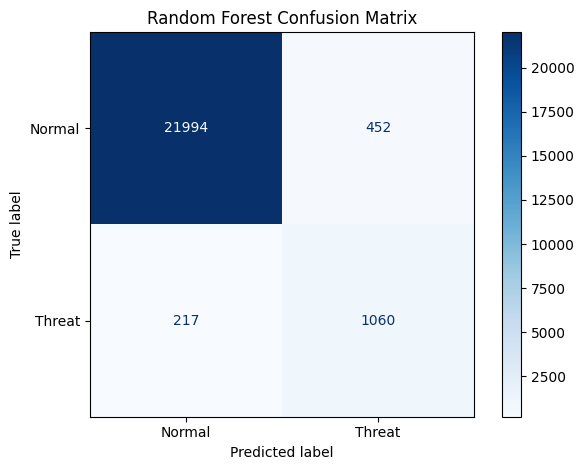

In [ ]:
#  RANDOM FOREST CONFUSION MATRIX (DISPLAY)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_y_pred,
    display_labels=["Normal", "Threat"],
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()


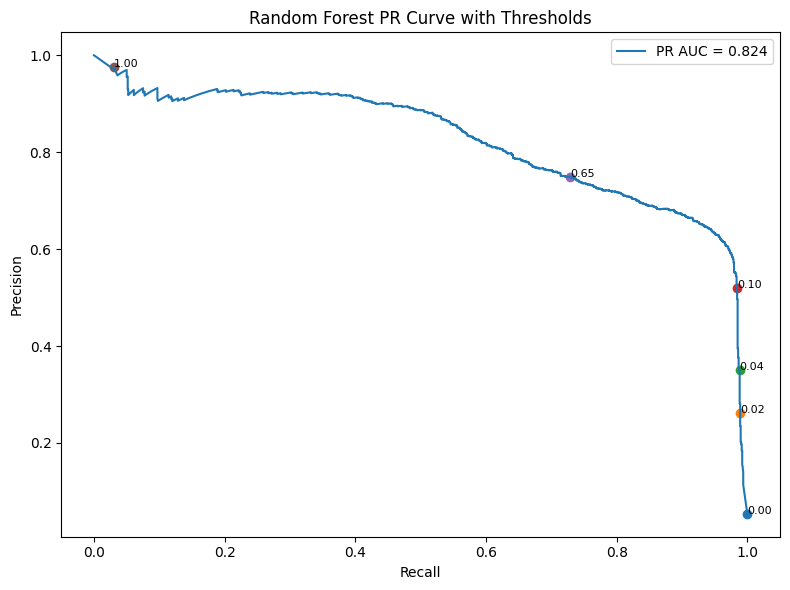

In [ ]:

# RANDOM FOREST PR CURVE (DISPLAY)

precision, recall, thresholds = precision_recall_curve(y_test, rf_y_prob)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR AUC = {rf_pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest PR Curve with Thresholds")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

# RANDOM FOREST FEATURE IMPORTANCE (DISPLAY)
print("Top 10 Random Forest Important Features:")
display(rf_importance.head(10))


Top 10 Random Forest Important Features:


,0
total_files_burned,0.231185
total_printed_pages,0.129490
employee_seniority_years,0.080129
num_unique_campus,0.045535
num_printed_pages_off_hours,0.044464
num_entries,0.034425
employee_classification,0.031386
burned_from_other,0.029856
entry_during_weekend,0.016934
employee_campus_Campus C,0.016630


In [ ]:

#  MODEL COMPARISON

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [log_roc_auc, rf_roc_auc],
    "PR-AUC": [log_pr_auc, rf_pr_auc],
    "F1 Score": [log_f1, rf_f1],
    "Accuracy": [log_acc, rf_acc]
})

display(comparison)

comparison.to_csv("model_comparison.csv", index=False)

plt.figure(figsize=(8, 4))
comparison.set_index("Model")[["ROC-AUC", "PR-AUC", "F1 Score", "Accuracy"]].plot(kind="bar")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight")
plt.close()

with mlflow.start_run(run_name="Model_Comparison"):
    mlflow.log_artifact("model_comparison.csv")
    mlflow.log_artifact("model_comparison.png")


,Model,ROC-AUC,PR-AUC,F1 Score,Accuracy
0,Logistic Regression,0.926292,0.615376,0.419262,0.880538
1,Random Forest,0.985253,0.824258,0.760129,0.971800


<Figure size 800x400 with 0 Axes>

In [16]:
from google.colab import files
import shutil

# Zip mlruns folder
shutil.make_archive("mlflow_data", 'zip', "mlruns")

# Download both DB and artifacts
files.download("mlflow.db")
files.download("mlflow_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>